In [143]:
import numpy as np

In [144]:
def conv2d(image, kernel):
    (k_h, k_w) = kernel.shape 
    (i_h, i_w) = image.shape 
    out_h = i_h - k_h + 1
    out_w = i_w - k_w + 1    
    feature_map = np.zeros((out_h, out_w), dtype=float)
    for i in range(out_h):
        for j in range(out_w):
            patch = image[i:i+k_h, j:j+k_w]
            value = np.sum(patch * kernel)
            feature_map[i,j] = value
    return feature_map

In [145]:
image = np.array([
    [1,2,3],
    [4,5,6],
    [7,8,9]
])
kernel = np.array([
    [1,0],
    [0,1]
])


In [146]:
out = conv2d(image,kernel)
out

array([[ 6.,  8.],
       [12., 14.]])

In [147]:
from sklearn.datasets import load_sample_image

image = load_sample_image("china.jpg")

# convert RGB to grayscale

image = np.mean(image, axis=2)



In [148]:
kernel = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1]
])

In [149]:
out = conv2d(image,kernel)
out.shape

(425, 638)

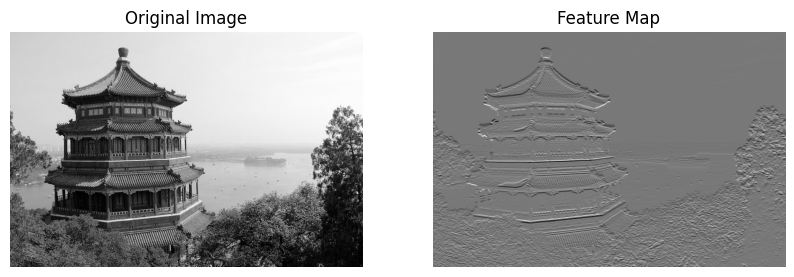

In [150]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

# original image
plt.subplot(1,2,1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

# feature map
plt.subplot(1,2,2)
plt.imshow(out, cmap="gray")
plt.title("Feature Map")
plt.axis("off")

plt.show()

In [151]:
kernel = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])

In [152]:
feature_map = conv2d(image, kernel)


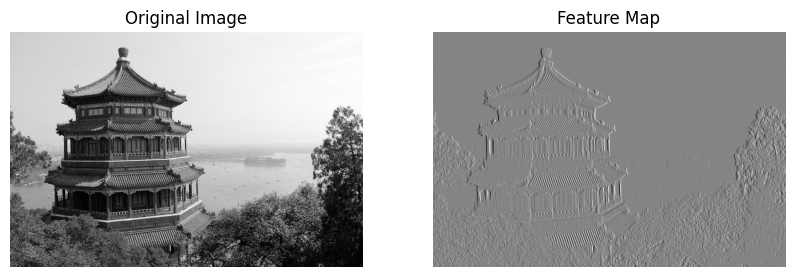

In [153]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

# original image
plt.subplot(1,2,1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

# feature map
plt.subplot(1,2,2)
plt.imshow(feature_map, cmap="gray")
plt.title("Feature Map")
plt.axis("off")

plt.show()

### Using pooling method


In [154]:
def max_pool2d(feature_map, pool_size=2, stride=2):
    (i_h, i_w) = feature_map.shape
    p_h = (i_h - pool_size) // stride + 1
    p_w = (i_w - pool_size) // stride + 1
    out = np.zeros((p_h, p_w), dtype=float)
    for i in range(p_h):
        for j in range(p_w):
            patch = feature_map[i*stride:i*stride+pool_size, j*stride:j*stride+pool_size]
            out[i, j] = np.max(patch)
    return out

In [155]:
# feature_map = np.array([
#     [1, 5, 2, 0],
#     [7, 3, 1, 2],
#     [4, 9, 8, 1],
#     [0, 2, 3, 6]
# ])
pooled_map = max_pool2d(feature_map)
print(pooled_map)

[[  1.           1.           3.         ...   4.33333333   2.33333333
    1.66666667]
 [  2.           0.           2.         ...   2.66666667   0.66666667
    0.        ]
 [  3.           2.           2.         ...   1.66666667  -1.
   -1.        ]
 ...
 [-11.33333333  10.33333333  22.         ...  13.33333333   2.66666667
    3.33333333]
 [ 10.          59.          33.         ...  56.33333333  38.
    9.        ]
 [ 70.          20.66666667  51.         ...  89.33333333  98.66666667
  -44.66666667]]


In [156]:
def mean_pool2d(feature_map, pool_size=2, stride=2):
    (i_h, i_w) = feature_map.shape
    p_h = (i_h - pool_size) // stride + 1
    p_w = (i_w - pool_size) // stride + 1
    out = np.zeros((p_h, p_w), dtype=float)
    for i in range(p_h):
        for j in range(p_w):
            patch = feature_map[i*stride:i*stride+pool_size, j*stride:j*stride+pool_size]
            out[i, j] = np.mean(patch)
    return out

In [ ]:
outs = mean_pool2d(feature_map)
# print(outs)

[[  1.           0.           2.5        ...   3.08333333   1.83333333
    0.58333333]
 [  1.25        -0.75         1.5        ...   2.25        -0.41666667
   -1.        ]
 [  2.75         1.           1.25       ...   0.83333333  -1.25
   -2.25      ]
 ...
 [-63.08333333 -32.58333333 -10.33333333 ...   8.08333333  -3.91666667
   -0.83333333]
 [-39.58333333  17.08333333 -15.83333333 ...  21.83333333  -1.33333333
   -8.66666667]
 [ -6.08333333 -17.58333333   4.75       ...  46.75        39.08333333
  -65.75      ]]


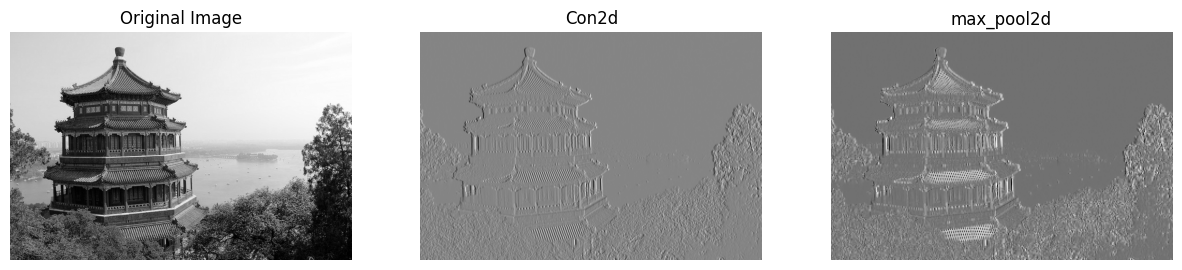

In [160]:
plt.figure(figsize=(15, 5))

plt.subplot(1,3,1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(feature_map,cmap="gray")
plt.title("Con2d")
plt.axis("off")


plt.subplot(1,3,3)
plt.imshow(pooled_map,cmap="gray")
plt.title("max_pool2d")
plt.axis("off")

plt.show()